16x8 lattice, D=8, chi=32, GPU: A100-80GB

<!-- bold=True

B=1: GPU 187.78s, CPU 83.05s
B=16: GPU 240.60s, CPU 357.08s
B=64: GPU 270.72s
B=128: GPU 309.92s
B=256: GPU 387.83s
B=512: GPU 548.04s -->


<!-- if using bold=3, the GPU batched bMPS contraction is really slow... -->
x-y TN reuse: 

B=1 GPU 232.32s CPU t=87.67s (threads=16), 
B=16 GPU 264.30s CPU 16t
B=64 GPU 297.71s CPU 64t
B=128 GPU 341.23s CPU 128t
B=256 GPU 430.34s CPU 256t
B=512 GPU 606.50s CPU 512t
B=800 GPU 787.96s CPU 800t

8x8 lattice TNF GPU: A100-80GB

<!-- D=chi=16
B=1 GPU 274.57s, CPU 186.38s
B=16 GPU 363.33s 
B=64 GPU 411.74s -->


D=chi=12
B=1 GPU 377.87s, CPU 154.57s
B=16 GPU 413.34s 
B=64 GPU 436.65s
B=128 GPU 451.54s, compiled 87.91s
B=256 GPU 535.11s, compiled 151.31s
B=512 GPU 695.26s, compiled 289.64s

16x12 lattice, one MC sweep, default CPU thread=16

D=8, chi=32
B=1: CPU 184.75s

D=10, chi=40
B=1: CPU 208.77s (251.61s for thread=1)

D=12, chi=48
B=1: CPU 289.32s

D=14, chi=56
B=1: CPU 506.96s (547.29s for thread=4)

D=16, chi=64
B=1: CPU 968.85s (thread=4)


Wenyuan's timing:

The following is the sampling time I used for 12x16 Hubbard model.

12x16 Hubbard model (cutoff Dc=4D);

D=8 , MC=20sweeps per core, wall time:  49min

D=10, MC=20sweeps per core, wall time:  56min

D=12, MC=20sweeps per core, wall time:  2.1  hours

D=14, MC=20sweeps per core, wall time:  5.5  hours

D=16, MC=20sweeps per core, wall time:  11.5 hours

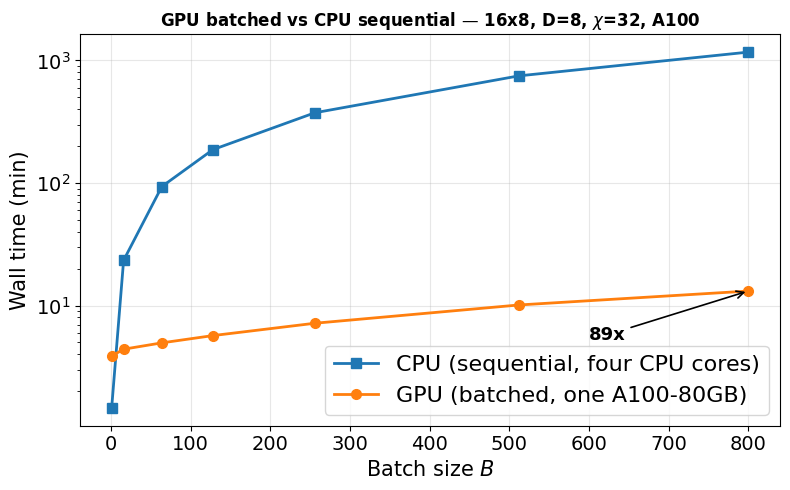

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Plot 1: Time vs batch size — GPU vs CPU
# 16x8 lattice, D=8, chi=32, GPU: A100-80GB
# CPU: sequential, 87.67s per sample (threads=16)
# ============================================================

B_arr = np.array([1, 16, 64, 128, 256, 512, 800])
gpu_s  = np.array([232.32, 264.30, 297.71, 341.23, 430.34, 606.50, 787.96])
cpu_per_sample = 87.67  # seconds, with 16 threads

# Convert to minutes
gpu_min = gpu_s / 60
cpu_min = B_arr * cpu_per_sample / 60

fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(B_arr, cpu_min, 's-', ms=7, lw=2, label='CPU (sequential, four CPU cores)')
ax.semilogy(B_arr, gpu_min, 'o-', ms=7, lw=2, label='GPU (batched, one A100-80GB)')

# Annotate speedup at B=800
speedup = cpu_min[-1] / gpu_min[-1]
ax.annotate(f'{speedup:.0f}x', xy=(800, gpu_min[-1]),
            xytext=(600, gpu_min[-1] * 0.4), fontsize=13, fontweight='bold',
            arrowprops=dict(arrowstyle='->', lw=1.2))

ax.set_xlabel('Batch size $B$', fontsize=15)
ax.set_ylabel('Wall time (min)', fontsize=15)
ax.set_title('GPU batched vs CPU sequential — 16x8, D=8, $\\chi$=32, A100',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=14)

fig.tight_layout()
plt.savefig('reuse_gpu_vs_cpu_batch.pdf', dpi=300, bbox_inches='tight')
plt.savefig('reuse_gpu_vs_cpu_batch.png', dpi=300, bbox_inches='tight')
plt.show()

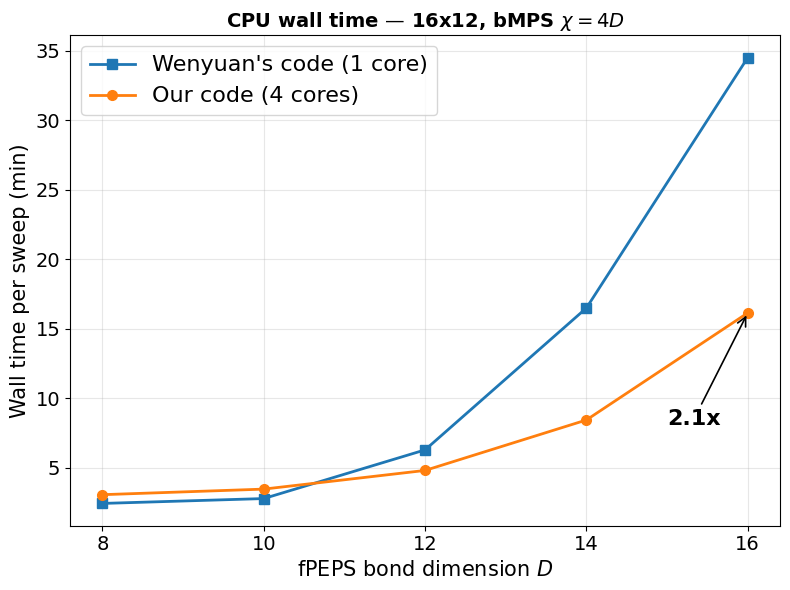

In [11]:
# ============================================================
# Plot 2: CPU wall time vs D — our code vs Wenyuan's
# 16x12 (=12x16) lattice, chi = 4D, one MC sweep
# ============================================================

D_arr = np.array([8, 10, 12, 14, 16])

# Our code: per sweep, threads=16 (D=14: 4 threads, D=16: 4 threads)
ours_s = np.array([184.75, 208.77, 289.32, 506.96, 968.85])

# Wenyuan's code: total wall time for 20 sweeps → per sweep
wenyuan_total_s = np.array([
    49 * 60,       # 49 min
    56 * 60,       # 56 min
    2.1 * 3600,    # 2.1 hours
    5.5 * 3600,    # 5.5 hours
    11.5 * 3600,   # 11.5 hours
])
wenyuan_s = wenyuan_total_s / 20  # per sweep

# Convert to minutes
ours_min = ours_s / 60
wenyuan_min = wenyuan_s / 60

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(D_arr, wenyuan_min, 's-', ms=7, lw=2, label="Wenyuan's code (1 core)") #  per chain, 200 chains in total
ax.plot(D_arr, ours_min, 'o-', ms=7, lw=2, label='Our code (4 cores)') # per chain, can have ~200 chains in total

# Annotate speedup at D=16
speedup = wenyuan_min[-1] / ours_min[-1]
ax.annotate(f'{speedup:.1f}x', xy=(16, ours_min[-1]),
            xytext=(15, ours_min[-1] * 0.5), fontsize=16, fontweight='bold',
            arrowprops=dict(arrowstyle='->', lw=1.2))

ax.set_xlabel('fPEPS bond dimension $D$', fontsize=15)
ax.set_ylabel('Wall time per sweep (min)', fontsize=15)
ax.set_title('CPU wall time — 16x12, bMPS $\\chi = 4D$',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
ax.set_xticks(D_arr)
ax.tick_params(labelsize=14)

fig.tight_layout()
plt.savefig('reuse_cpu_vs_D.pdf', dpi=300, bbox_inches='tight')
plt.savefig('reuse_cpu_vs_D.png', dpi=300, bbox_inches='tight')
plt.show()

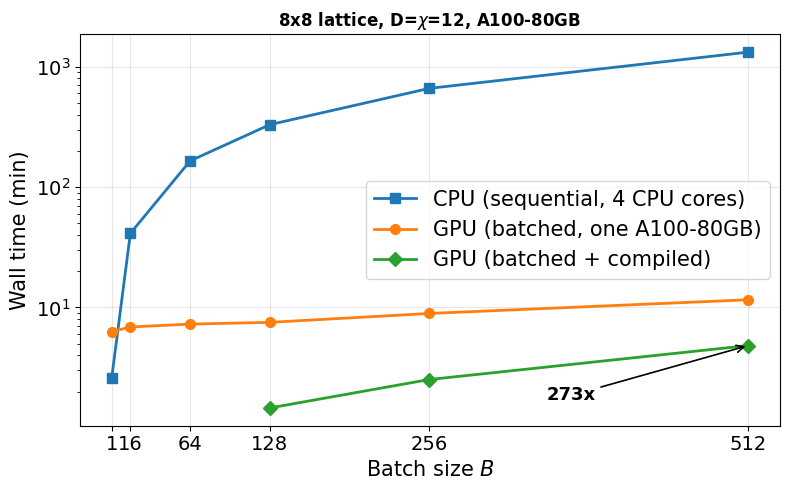

In [33]:
# ============================================================
# Plot 3: 8x8 lattice, D=chi=12, GPU vs compiled vs CPU
# GPU: A100-80GB
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
B_arr = np.array([1, 16, 64, 128, 256, 512])
gpu_s = np.array([377.87, 413.34, 436.65, 451.54, 535.11, 695.26])
compiled_s = np.array([np.nan, np.nan, np.nan, 87.91, 151.31, 289.64])
cpu_per_sample = 154.57  # B=1 CPU time

# CPU sequential: scales linearly with B
cpu_s = B_arr * cpu_per_sample

# Convert to minutes
gpu_min = gpu_s / 60
compiled_min = compiled_s / 60
cpu_min = cpu_s / 60

fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(B_arr, cpu_min, 's-', ms=7, lw=2, label='CPU (sequential, 4 CPU cores)')
ax.semilogy(B_arr, gpu_min, 'o-', ms=7, lw=2, label='GPU (batched, one A100-80GB)')
ax.semilogy(B_arr, compiled_min, 'D-', ms=7, lw=2,
            label='GPU (batched + compiled)')

# Annotate speedup at B=512 for compiled
speedup = cpu_min[-1] / compiled_min[-1]
ax.annotate(f'{speedup:.0f}x', xy=(512, compiled_min[-1]),
            xytext=(350, compiled_min[-1] * 0.35), fontsize=13, fontweight='bold',
            arrowprops=dict(arrowstyle='->', lw=1.2))

ax.set_xlabel('Batch size $B$', fontsize=15)
ax.set_ylabel('Wall time (min)', fontsize=15)
ax.set_title('8x8 lattice, D=$\\chi$=12, A100-80GB',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=15)
ax.grid(True, alpha=0.3)
ax.set_xticks(B_arr)
ax.tick_params(labelsize=14)

fig.tight_layout()
plt.savefig('reuse_gpu_compiled_cpu_batch.pdf', dpi=300, bbox_inches='tight')
plt.savefig('reuse_gpu_compiled_cpu_batch.png', dpi=300, bbox_inches='tight')
plt.show()

## Why batching helps: arithmetic intensity

Batching turns a for-loop of $k$ matrix-vector multiplications into a single matrix-matrix multiplication.

**Arithmetic intensity** = FLOPs / memory accesses.

For an $m \times n$ matrix times an $n \times k$ matrix:

$$I(m, n, k) = \frac{m n k}{m n + n k + m k}$$

- **Matrix-vector** ($k=1$): $\;I(m,n,1) = \frac{1}{1 + 1/m + 1/n} < 1$ — memory-bound.
- **Matrix-matrix** ($k \ll \min(m,n)$): $\;I(m,n,k) \approx k$ — compute-bound for large $k$.

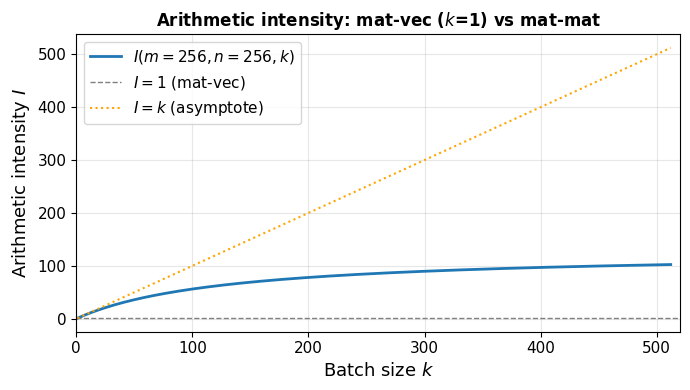

Device: cuda


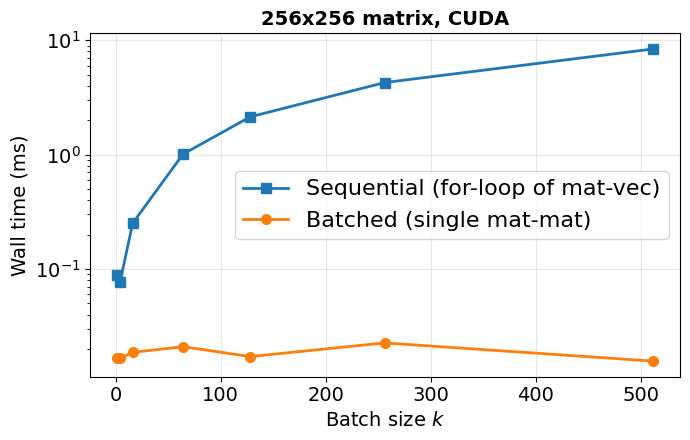


    k  Loop (ms)  Batch (ms)  Speedup
--------------------------------------
    1      0.089       0.017      5.3x
    4      0.077       0.017      4.6x
   16      0.252       0.019     13.5x
   64      1.011       0.021     48.3x
  128      2.143       0.017    124.9x
  256      4.271       0.023    189.0x
  512      8.410       0.016    536.9x


In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

# ============================================================
# Part 1: Theoretical arithmetic intensity I(m, n, k)
# ============================================================
def arith_intensity(m, n, k):
    return m * n * k / (m * n + n * k + m * k)

k_arr = np.arange(1, 513)
m, n = 256, 256  # square matrix

I_arr = arith_intensity(m, n, k_arr)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_arr, I_arr, lw=2, label=f'$I(m={m}, n={n}, k)$')
ax.axhline(1, color='gray', ls='--', lw=1, label='$I = 1$ (mat-vec)')
ax.plot(k_arr, k_arr, ls=':', color='orange', lw=1.5,
        label='$I = k$ (asymptote)')

ax.set_xlabel('Batch size $k$', fontsize=13)
ax.set_ylabel('Arithmetic intensity $I$', fontsize=13)
ax.set_title('Arithmetic intensity: mat-vec ($k$=1) vs mat-mat',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 520)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()

# ============================================================
# Part 2: Timing — sequential mat-vec loop vs batched mat-mat
# ============================================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

m, n = 256, 256
k_values = [1, 4, 16, 64, 128, 256, 512]
n_repeats = 20

A = torch.randn(m, n, device=device)

loop_times = []
batch_times = []

for k in k_values:
    V = torch.randn(n, k, device=device)

    # --- Sequential: k mat-vec products in a for-loop ---
    torch.cuda.synchronize() if device == 'cuda' else None
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        results = []
        for j in range(k):
            results.append(A @ V[:, j])
        out_loop = torch.stack(results, dim=1)
    torch.cuda.synchronize() if device == 'cuda' else None
    loop_times.append((time.perf_counter() - t0) / n_repeats)

    # --- Batched: single mat-mat ---
    torch.cuda.synchronize() if device == 'cuda' else None
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        out_batch = A @ V
    torch.cuda.synchronize() if device == 'cuda' else None
    batch_times.append((time.perf_counter() - t0) / n_repeats)

loop_times = np.array(loop_times) * 1e3   # ms
batch_times = np.array(batch_times) * 1e3  # ms
speedups = loop_times / batch_times

# --- Plot timing comparison ---
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.semilogy(k_values, loop_times, 's-', ms=7, lw=2,
            label='Sequential (for-loop of mat-vec)')
ax.semilogy(k_values, batch_times, 'o-', ms=7, lw=2,
            label='Batched (single mat-mat)')
ax.set_xlabel('Batch size $k$', fontsize=14)
ax.set_ylabel('Wall time (ms)', fontsize=14)
ax.set_title(f'{m}x{n} matrix, {device.upper()}', fontsize=14,
             fontweight='bold')
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=14)

fig.tight_layout()
plt.show()

# Print table
print(f"\n{'k':>5} {'Loop (ms)':>10} {'Batch (ms)':>11} {'Speedup':>8}")
print("-" * 38)
for k, lt, bt, s in zip(k_values, loop_times, batch_times, speedups):
    print(f"{k:>5} {lt:>10.3f} {bt:>11.3f} {s:>8.1f}x")